<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Group_R_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Install and import Keras Tuner
!pip install -q -U keras-tuner
import keras_tuner as kt

print(" Step 1: Connecting to Google Drive...")
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.6 MB/s eta 0:00:00
 Step 1: Connecting to Google Drive...
Mounted at /content/drive


In [2]:
# 2. LOCATE AND LOAD THE SUPER-DATASET

print("\n Step 2: Loading preprocessed Super-Dataset...")
search_pattern = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
matching_files = glob.glob(search_pattern)

if len(matching_files) == 0:
    matching_files = glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(matching_files) > 0:
    file_path = matching_files[0]
    df_super = pd.read_csv(file_path)
    print(f" SUCCESS! Loaded dataset from: {file_path}")
else:
    raise FileNotFoundError(" ERROR: Could not find 'super_dataset_C_train.csv'.")

# Clean column headers
df_super.columns = [re.sub(r'[\[\]<>]', '', col) for col in df_super.columns]

# Split features and labels
y_model = df_super['covid_vaccine'].values
X_model = df_super.drop(columns=['covid_vaccine']).values

X_train, X_val, y_train, y_val = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

# Reshape into 3D format [samples, time_steps, features] for LSTM
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

# Account for 2:1 class imbalance
class_weights = {0: 1.0, 1: 2.0}



 Step 2: Loading preprocessed Super-Dataset...
 SUCCESS! Loaded dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv



================  SVM Model Implementation
Initializing and training SVM Classifier...
SVM training complete.

Evaluating the SVM model...

================  SVM EVALUATION REPORT  ================ 
SVM Validation ROC-AUC: 0.8165

                    precision    recall  f1-score   support

Not Vaccinated (0)       0.85      0.81      0.83       641
    Vaccinated (1)       0.64      0.69      0.66       311

          accuracy                           0.77       952
         macro avg       0.74      0.75      0.75       952
      weighted avg       0.78      0.77      0.77       952



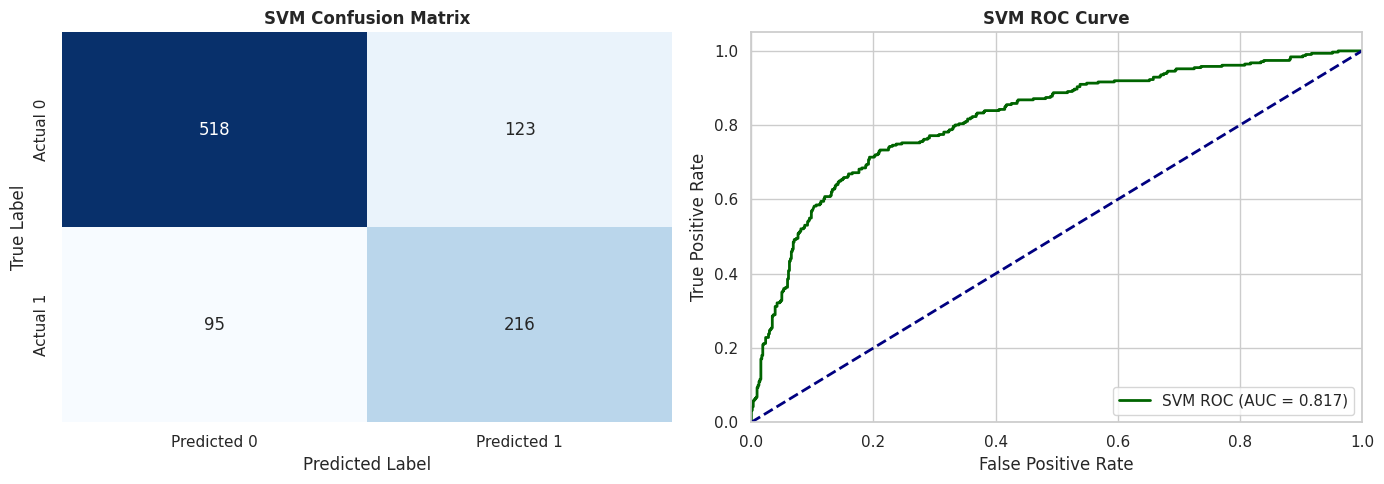


SVM charts saved directly to shared Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/team_svm_evaluation.png


In [3]:
print("\n================  SVM Model Implementation")

# 1. Import necessary libraries for SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Data Scaling for SVM (important for distance-based algorithms like SVM)
# It's good practice to scale features for SVM. The data was already somewhat scaled
# during initial preprocessing, but StandardScaler is robust for SVM.
scaler_svm = StandardScaler()
X_train_scaled_svm = scaler_svm.fit_transform(X_train)
X_val_scaled_svm = scaler_svm.transform(X_val)

# 3. Initialize and train the SVM Classifier
print("Initializing and training SVM Classifier...")
# Using class_weight='balanced' to handle the imbalance, similar to what was done for LSTM
svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled_svm, y_train)
print("SVM training complete.")

# 4. Evaluate the SVM model
print("\nEvaluating the SVM model...")
y_pred_svm = svm_model.predict(X_val_scaled_svm)
y_pred_proba_svm = svm_model.predict_proba(X_val_scaled_svm)[:, 1]

print("\n================  SVM EVALUATION REPORT  ================ ")
svm_auc = roc_auc_score(y_val, y_pred_proba_svm)
print(f"SVM Validation ROC-AUC: {svm_auc:.4f}\n")
print(classification_report(y_val, y_pred_svm, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))

# 5. Draw Dashboards for SVM
sns.set_theme(style="whitegrid")
fig_svm, axes_svm = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_val, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes_svm[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes_svm[0].set_title('SVM Confusion Matrix', fontweight='bold')
axes_svm[0].set_xlabel('Predicted Label')
axes_svm[0].set_ylabel('True Label')

# ROC Curve for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_val, y_pred_proba_svm)
axes_svm[1].plot(fpr_svm, tpr_svm, color='darkgreen', lw=2, label=f'SVM ROC (AUC = {svm_auc:.3f})')
axes_svm[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes_svm[1].set_xlim([0.0, 1.0])
axes_svm[1].set_ylim([0.0, 1.05])
axes_svm[1].set_xlabel('False Positive Rate')
axes_svm[1].set_ylabel('True Positive Rate')
axes_svm[1].set_title('SVM ROC Curve', fontweight='bold')
axes_svm[1].legend(loc="lower right")

plt.tight_layout()

# Save final graphic to your shared Drive
output_plot_path_svm = file_path.replace('super_dataset_C_train.csv', 'team_svm_evaluation.png')
plt.savefig(output_plot_path_svm, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSVM charts saved directly to shared Drive folder:\n   {output_plot_path_svm}")



================  Hyperparameter Tuning for SVM  ================ 
Starting GridSearchCV for SVM... This may take some time depending on the grid size and data.
Fitting 3 folds for each of 12 candidates, totalling 36 fits

================  OPTIMAL SVM PARAMETERS FOUND ================
 Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
 Best SVM Validation ROC-AUC (from GridSearchCV): 0.8312

Training the finalized SVM model using optimal configurations...
Tuned SVM model training complete.

Evaluating the tuned SVM model...

================  TUNED SVM EVALUATION REPORT  ================ 
 Tuned SVM Validation ROC-AUC: 0.8314

                    precision    recall  f1-score   support

Not Vaccinated (0)       0.86      0.80      0.83       641
    Vaccinated (1)       0.64      0.74      0.68       311

          accuracy                           0.78       952
         macro avg       0.75      0.77      0.76       952
      weighted avg       0.79      0.78   

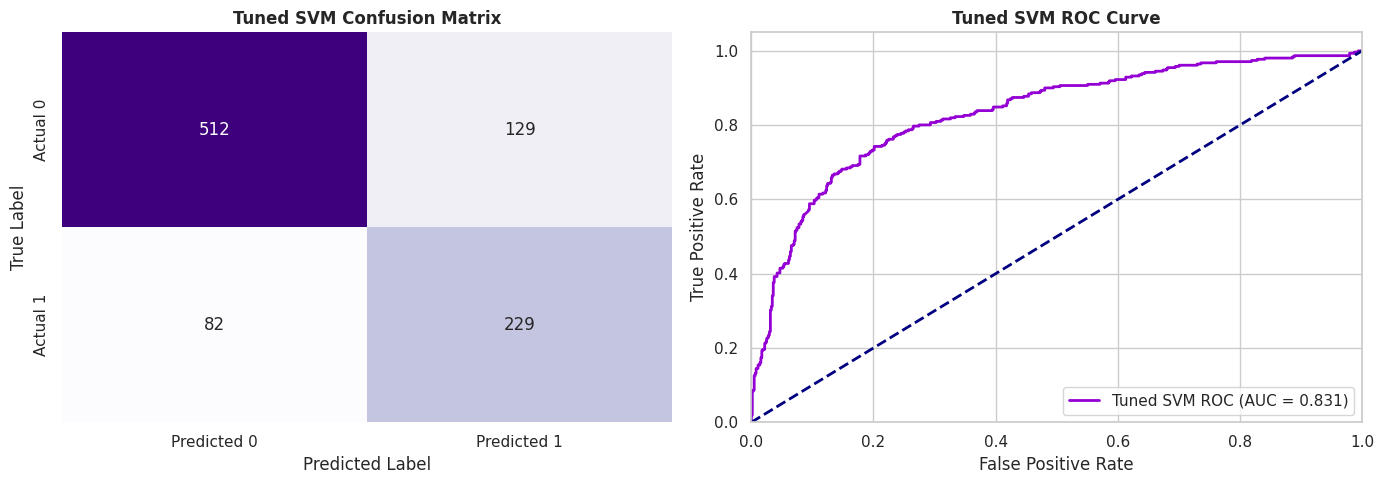


Tuned SVM charts saved directly to shared Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/team_svm_tuned_evaluation.png


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\n================  Hyperparameter Tuning for SVM  ================ ")

# Define the parameter grid for GridSearchCV
# We'll search for optimal C, kernel, and gamma values.
# Given the dataset size, a moderate grid is chosen to balance thoroughness and computational time.
param_grid = {
    'C': [0.1, 1, 10],            # Regularization parameter: smaller C means stronger regularization
    'kernel': ['rbf', 'linear'],  # Kernel type: 'rbf' (Radial Basis Function) and 'linear' are common choices
    'gamma': ['scale', 'auto']    # Kernel coefficient for 'rbf' and 'poly'. 'scale' uses 1 / (n_features * X.var()) and 'auto' uses 1 / n_features
}

# Initialize GridSearchCV
# We'll use 'roc_auc' as the scoring metric, consistent with our previous LSTM tuning objective.
# cv=3 specifies 3-fold cross-validation.
# n_jobs=-1 uses all available CPU cores for parallel processing, speeding up the search.
grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42, class_weight='balanced'), # Ensure probability=True for ROC-AUC scoring
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Starting GridSearchCV for SVM... This may take some time depending on the grid size and data.")
# Fit GridSearchCV to the scaled training data
# X_train_scaled_svm and y_train are available from previous data preprocessing steps
grid_search.fit(X_train_scaled_svm, y_train)

# Get the best parameters and the best score found by GridSearchCV
best_svm_hps = grid_search.best_params_
best_svm_auc = grid_search.best_score_

print("OPTIMAL SVM PARAMETERS FOUND ")
print(f" Best SVM Parameters: {best_svm_hps}")
print(f" Best SVM Validation ROC-AUC (from GridSearchCV): {best_svm_auc:.4f}\n")

# Train the final SVM model with the best parameters found
print("Training the finalized SVM model using optimal configurations...")
tuned_svm_model = SVC(probability=True, random_state=42, class_weight='balanced', **best_svm_hps)
tuned_svm_model.fit(X_train_scaled_svm, y_train)
print("Tuned SVM model training complete.")

# Evaluate the tuned SVM model on the validation set
print("\nEvaluating the tuned SVM model...")
y_pred_tuned_svm = tuned_svm_model.predict(X_val_scaled_svm)
y_pred_proba_tuned_svm = tuned_svm_model.predict_proba(X_val_scaled_svm)[:, 1]

print("TUNED SVM EVALUATION REPORT ")
tuned_svm_auc = roc_auc_score(y_val, y_pred_proba_tuned_svm)
print(f" Tuned SVM Validation ROC-AUC: {tuned_svm_auc:.4f}\n")
# Display the classification report with precision, recall, f1-score, and support
print(classification_report(y_val, y_pred_tuned_svm, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))

# Generate and display evaluation plots for the tuned SVM model
sns.set_theme(style="whitegrid")
fig_tuned_svm, axes_tuned_svm = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Tuned SVM
cm_tuned_svm = confusion_matrix(y_val, y_pred_tuned_svm)
sns.heatmap(cm_tuned_svm, annot=True, fmt='d', cmap='Purples', ax=axes_tuned_svm[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes_tuned_svm[0].set_title('Tuned SVM Confusion Matrix', fontweight='bold')
axes_tuned_svm[0].set_xlabel('Predicted Label')
axes_tuned_svm[0].set_ylabel('True Label')

# ROC Curve for Tuned SVM
fpr_tuned_svm, tpr_tuned_svm, _ = roc_curve(y_val, y_pred_proba_tuned_svm)
axes_tuned_svm[1].plot(fpr_tuned_svm, tpr_tuned_svm, color='darkviolet', lw=2, label=f'Tuned SVM ROC (AUC = {tuned_svm_auc:.3f})')
axes_tuned_svm[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes_tuned_svm[1].set_xlim([0.0, 1.0])
axes_tuned_svm[1].set_ylim([0.0, 1.05])
axes_tuned_svm[1].set_xlabel('False Positive Rate')
axes_tuned_svm[1].set_ylabel('True Positive Rate')
axes_tuned_svm[1].set_title('Tuned SVM ROC Curve', fontweight='bold')
axes_tuned_svm[1].legend(loc="lower right")

plt.tight_layout()

# Save the evaluation graphic to your shared Drive
# The 'file_path' variable should be available from the data loading cell (c-xjgsvwoSne).
output_plot_path_tuned_svm = file_path.replace('super_dataset_C_train.csv', 'team_svm_tuned_evaluation.png')
plt.savefig(output_plot_path_tuned_svm, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTuned SVM charts saved directly to shared Drive folder:\n   {output_plot_path_tuned_svm}")


In [14]:
# 1. LOAD THE PREPROCESSED TEST DATASET

import glob
import pandas as pd

print(" Locating the preprocessed test super-dataset...")
search_test = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_test.csv'
test_files = glob.glob(search_test) or glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_test.csv')

if len(test_files) > 0:
    df_test = pd.read_csv(test_files[0])
    print(f" SUCCESS! Loaded Test Super-Dataset from: {test_files[0]}")
else:
    raise FileNotFoundError(" ERROR: Could not find 'super_dataset_C_test.csv' in the shared Drive folder.")

# Isolate features and tracking IDs
test_ids = df_test['respondent_id']
X_test_final = df_test.drop(columns=['respondent_id'])

# 2. PREPROCESS AND GENERATE PREDICTIONS WITH YOUR TUNED MODEL
print("\n Scaling test features and passing through your active tuned model...")

# Scale the test features using the *same scaler* fitted on the training data
# `scaler_svm` is defined in cell Jk0aGQBT9tY-
X_test_final_scaled = scaler_svm.transform(X_test_final)

# Make predictions using the 'tuned_svm_model' variable from cell qbGMDHIX9vUb
test_probabilities = tuned_svm_model.predict_proba(X_test_final_scaled)[:, 1]

# 3. EXPORT FINAL HACKATHON SUBMISSION FILE

submission_df = pd.DataFrame({
    'respondent_id': test_ids,
    'covid_vaccine_probability': test_probabilities
})

submission_output_path = test_files[0].replace('super_dataset_C_test.csv', 'svm_final_predictions_submission.csv')
submission_df.to_csv(submission_output_path, index=False)

print("EXPORT SUCCESS ")
print(f" Final prediction table compiled successfully!")
print(f" File exported directly to shared Drive folder at:\n   {submission_output_path}")
print(f" Matrix Dimensions: {submission_df.shape[0]} test survey responses scored.")


 Locating the preprocessed test super-dataset...
 SUCCESS! Loaded Test Super-Dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_test.csv

 Scaling test features and passing through your active tuned model...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



================  EXPORT SUCCESS ================
 Final prediction table compiled successfully!
 File exported directly to shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/svm_final_predictions_submission.csv
 Matrix Dimensions: 4749 test survey responses scored.
